[*********************100%***********************]  1 of 1 completed


CSV file has been created successfully!
Model Confidence (R2 Score): 0.97


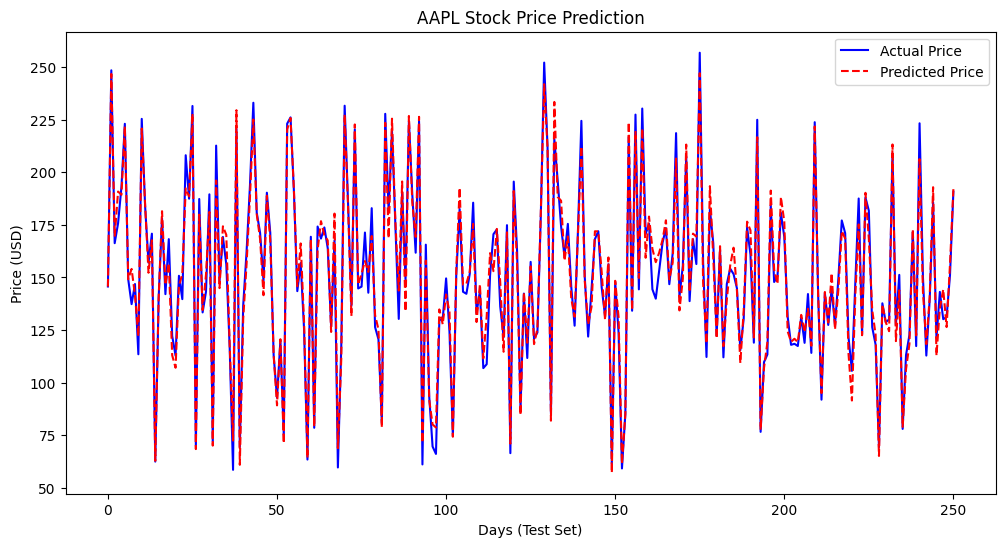

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. Fetching the Data
ticker = 'AAPL'  # You can change this to TSLA, GOOGL, etc.
data = yf.download(ticker, start="2020-01-01", end="2025-01-01")
# Add this right after the 'data = yf.download(...)' line
data.to_csv("stock_data.csv")
print("CSV file has been created successfully!")

# 2. Preprocessing
# We want to predict the 'Close' price based on the previous day's data
data['Date'] = data.index
data = data[['Close']]
forecast_out = 7  # Predicting 1 day into the future
data['Prediction'] = data[['Close']].shift(-forecast_out)

# Define Features (X) and Target (y)
X = np.array(data.drop(['Prediction'], axis=1))
X = X[:-forecast_out] # Remove last row which has NaN prediction
y = np.array(data['Prediction'])
y = y[:-forecast_out]

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Building the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Testing & Accuracy
predictions = model.predict(X_test)
print(f"Model Confidence (R2 Score): {model.score(X_test, y_test):.2f}")

# 6. Visualization
plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red', linestyle='--')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()